# **Aashish Shrestha**
## **Data Cleaning and EDA**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/winequality-red.csv")

In [ ]:
data.shape

(1599, 12)

In [ ]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
data.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
data.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [ ]:
data.columns = data.columns.str.replace(' ', '_').str.lower()
print("Cleaned column names:", data.columns.tolist())

Cleaned column names: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol', 'quality']


In [ ]:
missing_values = data.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

Missing values per column:
Series([], dtype: int64)


In [ ]:
# Check for duplicate rows
duplicates = data.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Remove duplicates
data = data.drop_duplicates()
print(f"Shape after removing duplicates: {data.shape}")


Number of duplicate rows: 240
Shape after removing duplicates: (1359, 12)


In [ ]:
# Identify outliers using IQR method
def detect_outliers_iqr(data):
    outliers = {}
    for col in data.select_dtypes(include=[np.number]).columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers[col] = data[(data[col] < lower_bound) | (data[col] > upper_bound)].shape[0]
    return outliers

outliers_count = detect_outliers_iqr(data)
print("\nPotential outliers per column (IQR method):")
for col, count in outliers_count.items():
    if count > 0:
        print(f"{col}: {count} potential outliers")


Potential outliers per column (IQR method):
fixed_acidity: 41 potential outliers
volatile_acidity: 19 potential outliers
citric_acid: 1 potential outliers
residual_sugar: 126 potential outliers
chlorides: 87 potential outliers
free_sulfur_dioxide: 26 potential outliers
total_sulfur_dioxide: 45 potential outliers
density: 35 potential outliers
ph: 28 potential outliers
sulphates: 55 potential outliers
alcohol: 12 potential outliers
quality: 27 potential outliers


In [ ]:
# Check skewness of numerical features
skewness = data.skew().sort_values(ascending=False)
print("\nSkewness of features:")
print(skewness)

# Identify highly skewed features (absolute skew > 0.5)
highly_skewed = skewness[abs(skewness) > 0.5]
print(f"\nFeatures with high skewness (|skew| > 0.5): {len(highly_skewed)}")
print(highly_skewed)


Skewness of features:
chlorides               5.502487
residual_sugar          4.548153
sulphates               2.406505
total_sulfur_dioxide    1.540368
free_sulfur_dioxide     1.226579
fixed_acidity           0.941041
alcohol                 0.859841
volatile_acidity        0.729279
citric_acid             0.312726
ph                      0.232032
quality                 0.192407
density                 0.044778
dtype: float64

Features with high skewness (|skew| > 0.5): 8
chlorides               5.502487
residual_sugar          4.548153
sulphates               2.406505
total_sulfur_dioxide    1.540368
free_sulfur_dioxide     1.226579
fixed_acidity           0.941041
alcohol                 0.859841
volatile_acidity        0.729279
dtype: float64


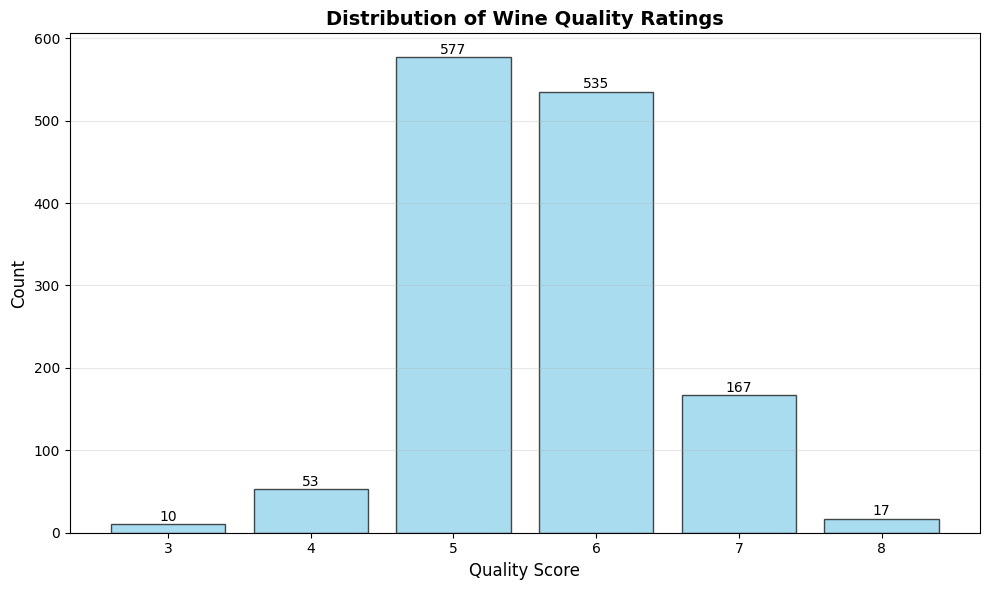

In [ ]:
plt.figure(figsize=(10, 6))
quality_counts = data['quality'].value_counts().sort_index()
bars = plt.bar(quality_counts.index, quality_counts.values,
               color='skyblue', edgecolor='black', alpha=0.7)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom')

plt.xlabel('Quality Score', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Wine Quality Ratings', fontsize=14, fontweight='bold')
plt.xticks(quality_counts.index)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

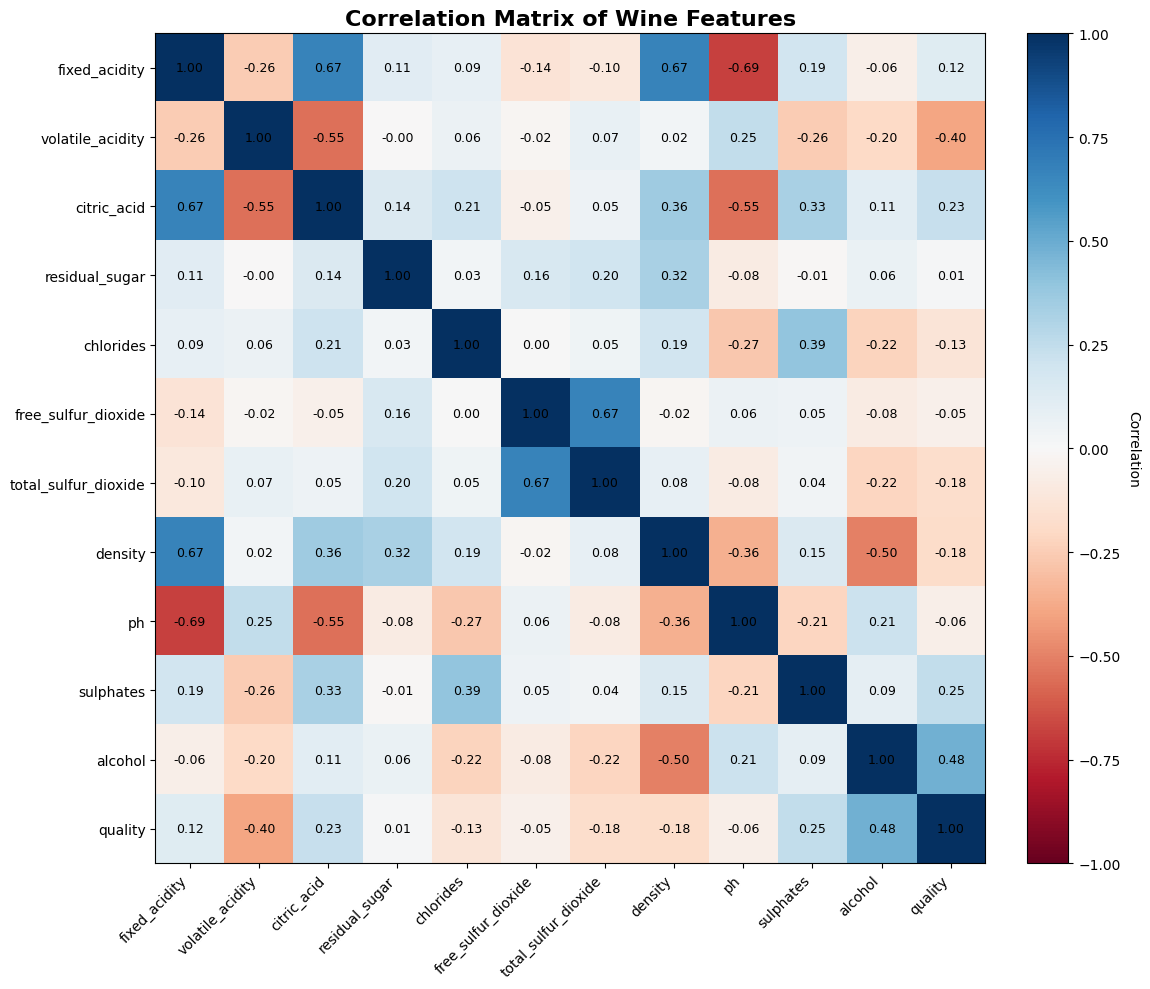


Top 5 features positively correlated with quality:
alcohol           0.480343
sulphates         0.248835
citric_acid       0.228057
fixed_acidity     0.119024
residual_sugar    0.013640
Name: quality, dtype: float64

Top 5 features negatively correlated with quality:
ph                     -0.055245
chlorides              -0.130988
total_sulfur_dioxide   -0.177855
density                -0.184252
volatile_acidity       -0.395214
Name: quality, dtype: float64


In [ ]:
# Calculate correlation matrix
# Exclude non-numeric columns like 'quality_category' for correlation calculation
numeric_data = data.select_dtypes(include=np.number)
corr_matrix = numeric_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='RdBu', vmin=-1, vmax=1)

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel('Correlation', rotation=-90, va="bottom")

# Set ticks and labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)

# Add correlation values as text
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=9)

ax.set_title('Correlation Matrix of Wine Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Top features correlated with quality
quality_corr = corr_matrix['quality'].sort_values(ascending=False)
print("\nTop 5 features positively correlated with quality:")
print(quality_corr[1:6])
print("\nTop 5 features negatively correlated with quality:")
print(quality_corr[-5:])

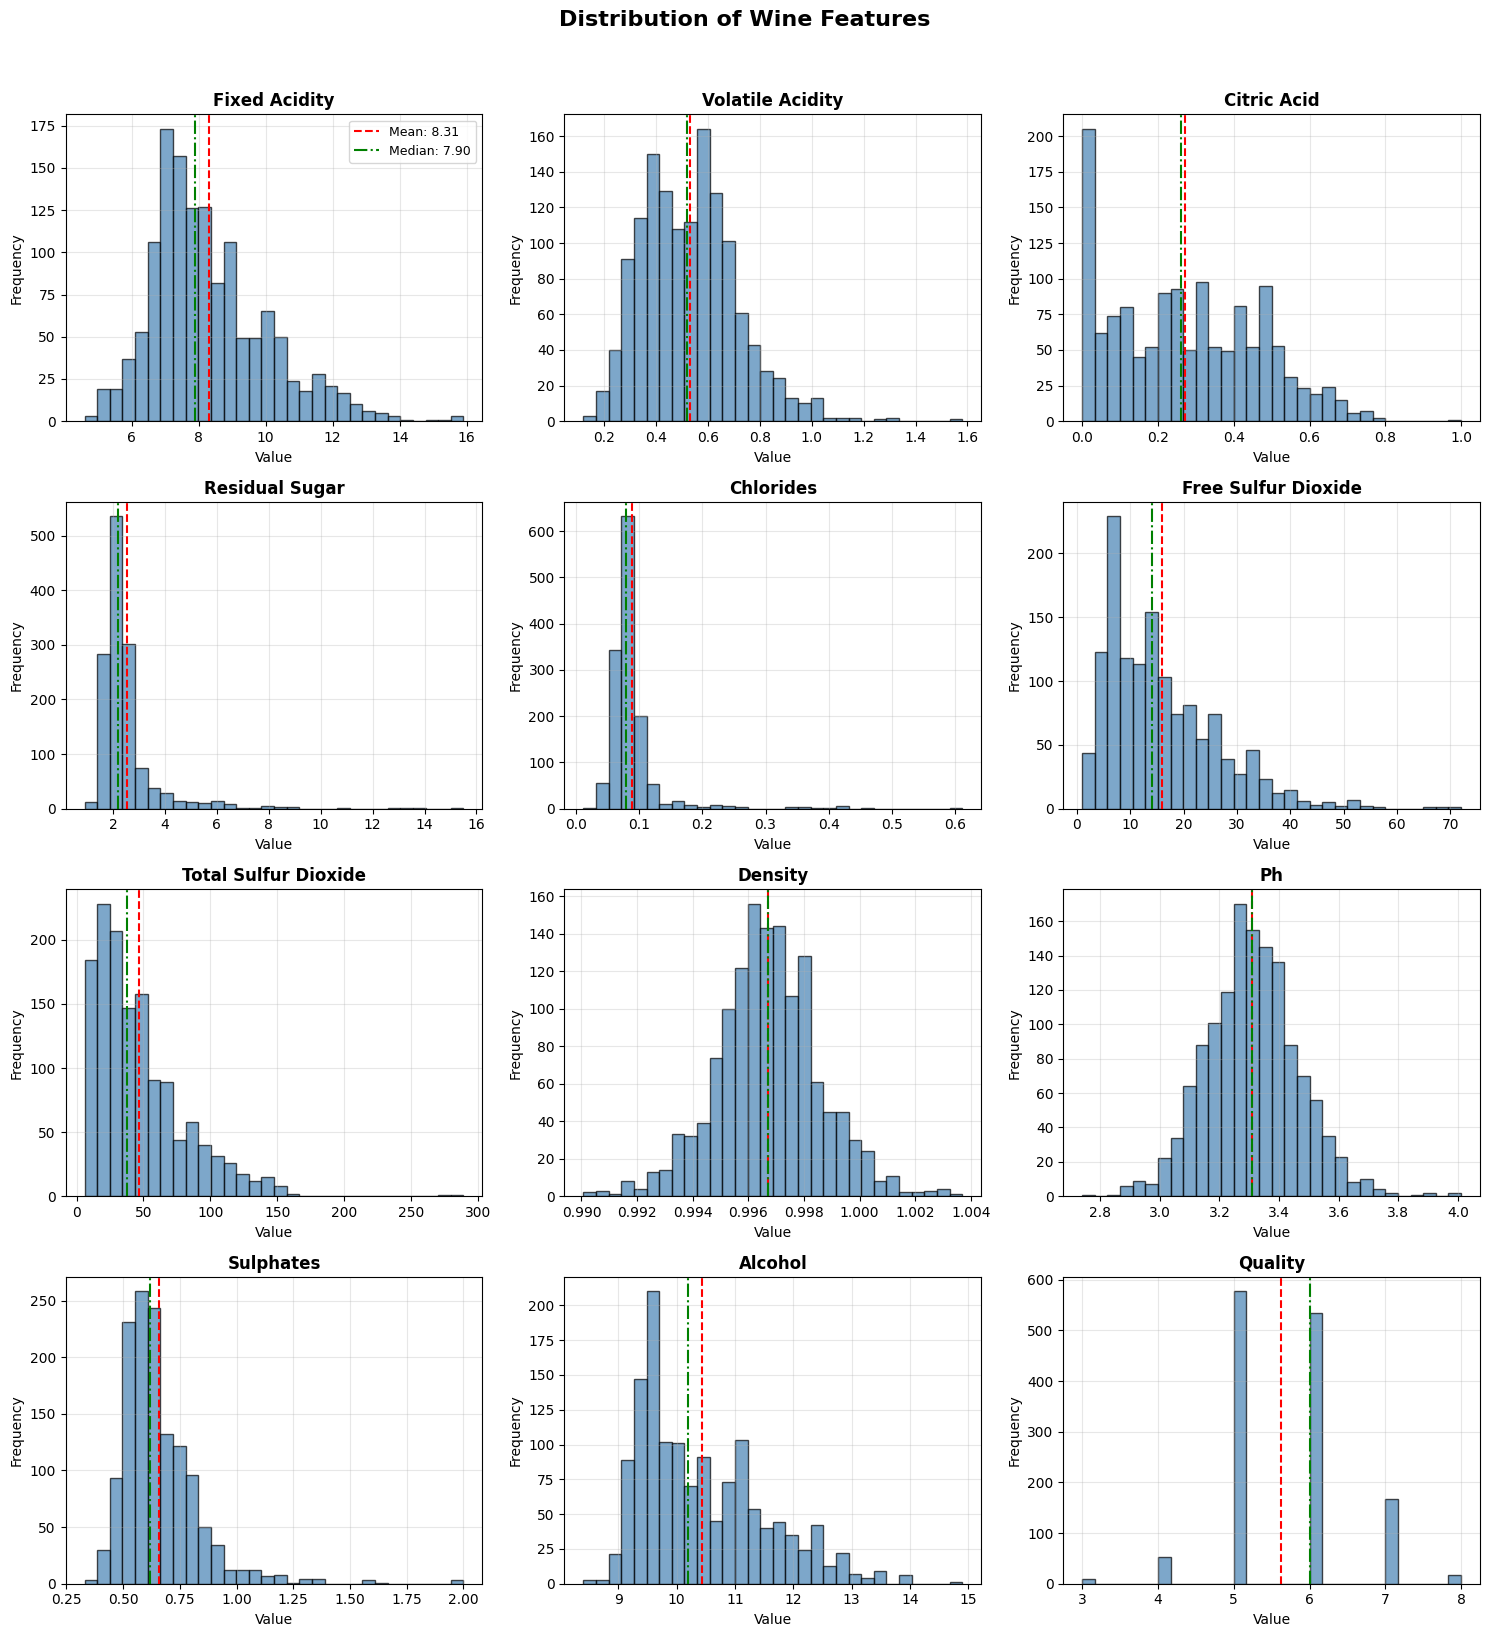

In [ ]:
# Create histogram grid for all features
numeric_cols = data.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Histogram
    axes[i].hist(data[col], bins=30, color='steelblue',
                 edgecolor='black', alpha=0.7)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(alpha=0.3)

    # Add mean and median lines
    mean_val = data[col].mean()
    median_val = data[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-.', linewidth=1.5,
                    label=f'Median: {median_val:.2f}')

    if i == 0:  # Add legend only to first plot to save space
        axes[i].legend(fontsize=9)

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Wine Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

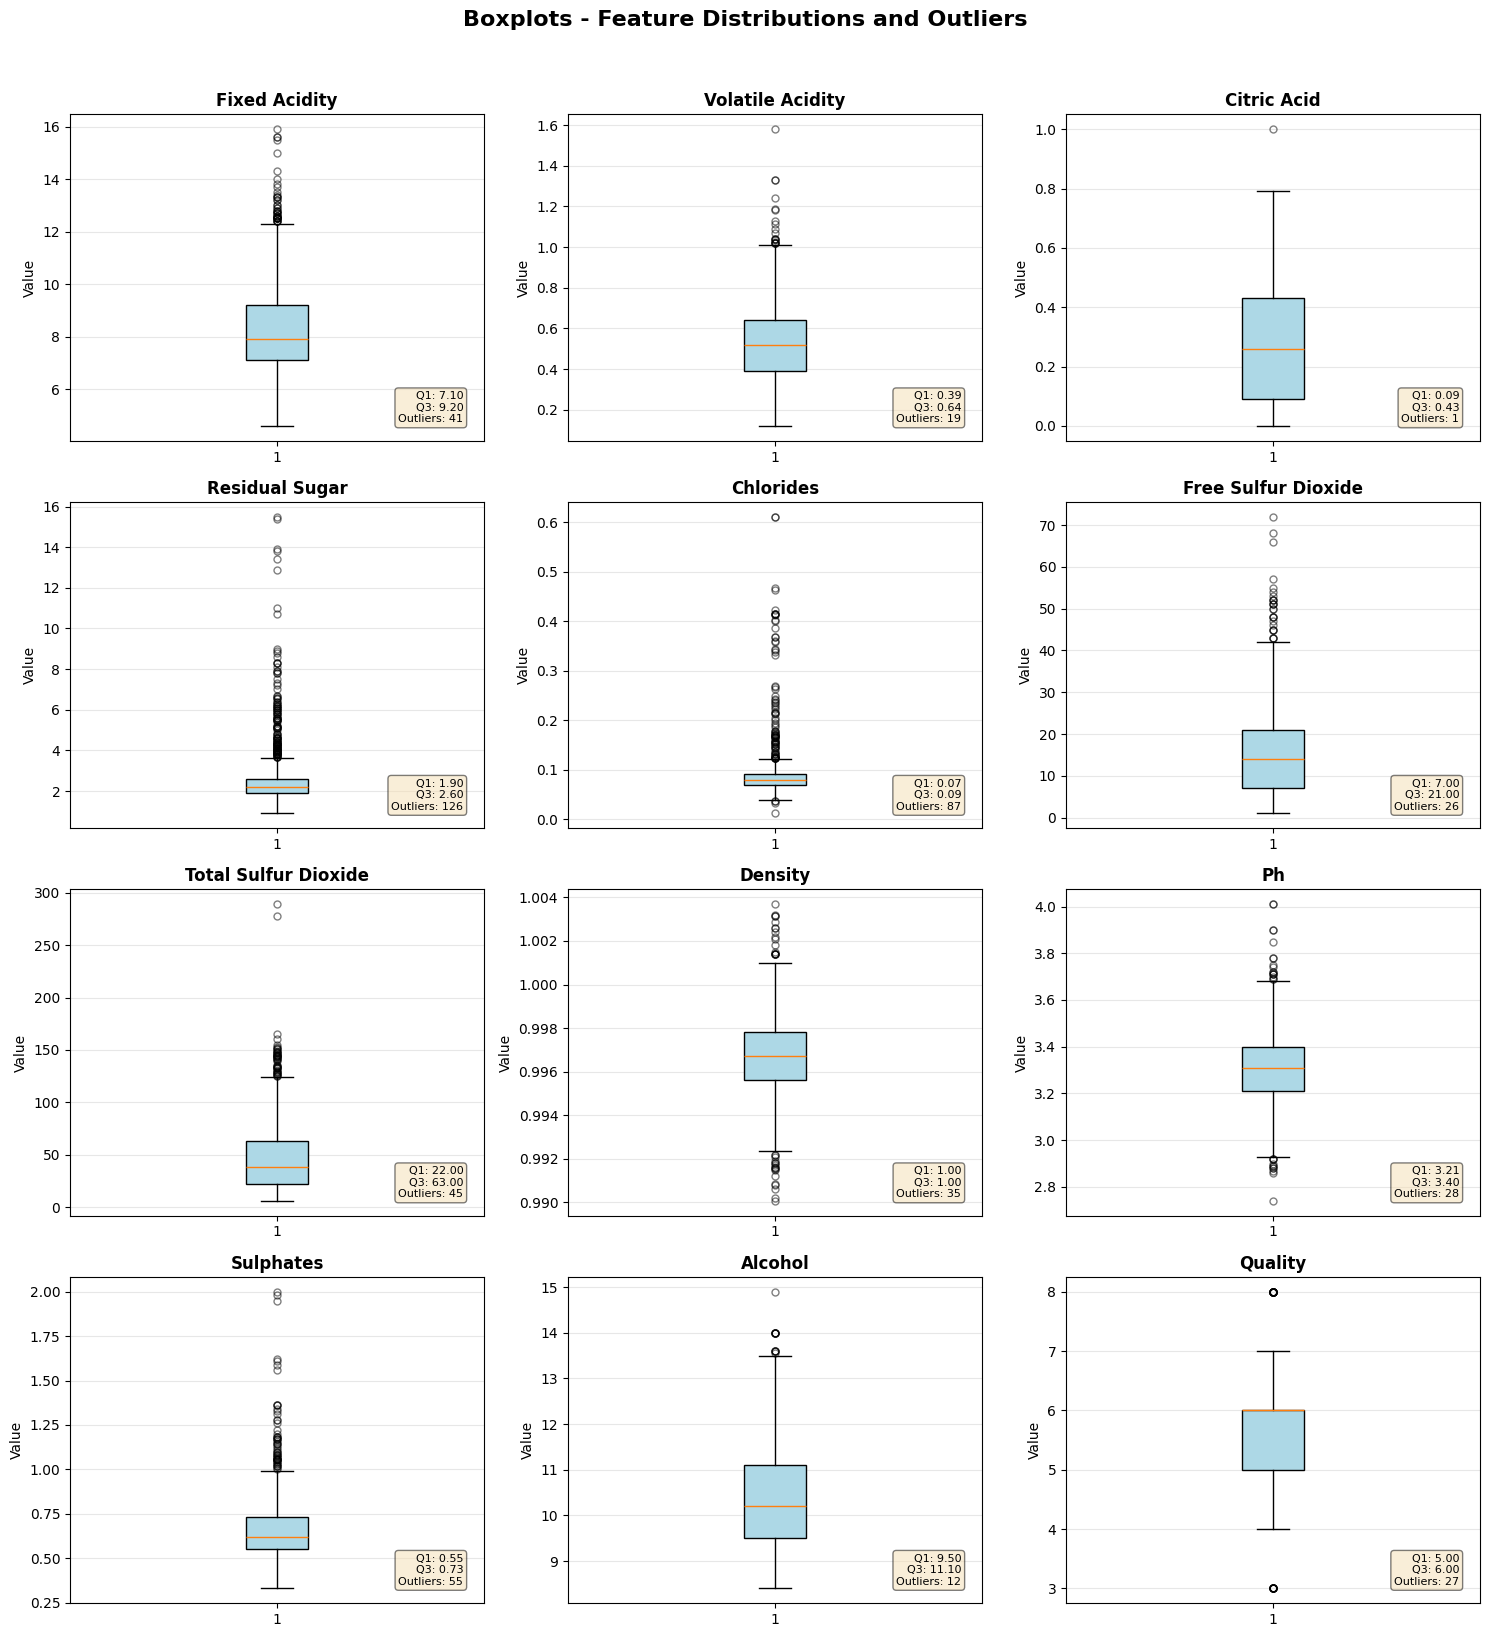

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Create boxplot
    bp = axes[i].boxplot(data[col], patch_artist=True,
                         boxprops=dict(facecolor='lightblue'))

    # Style outliers
    for flier in bp['fliers']:
        flier.set(marker='o', color='red', alpha=0.5, markersize=5)

    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', alpha=0.3)

    # Add feature statistics as text
    stats_text = f"Q1: {data[col].quantile(0.25):.2f}\n"
    stats_text += f"Q3: {data[col].quantile(0.75):.2f}\n"
    stats_text += f"Outliers: {sum((data[col] < data[col].quantile(0.25) - 1.5*(data[col].quantile(0.75)-data[col].quantile(0.25))) | (data[col] > data[col].quantile(0.75) + 1.5*(data[col].quantile(0.75)-data[col].quantile(0.25))))}"

    axes[i].text(0.95, 0.05, stats_text, transform=axes[i].transAxes,
                 fontsize=8, verticalalignment='bottom',
                 horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Feature Distributions and Outliers',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Make a copy (important)
data_outlier_treated = data.copy()

# Numeric columns only (exclude target if needed)
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('quality', errors='ignore')

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data[col] = data[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier treatment completed using IQR capping.")


Outlier treatment completed using IQR capping.


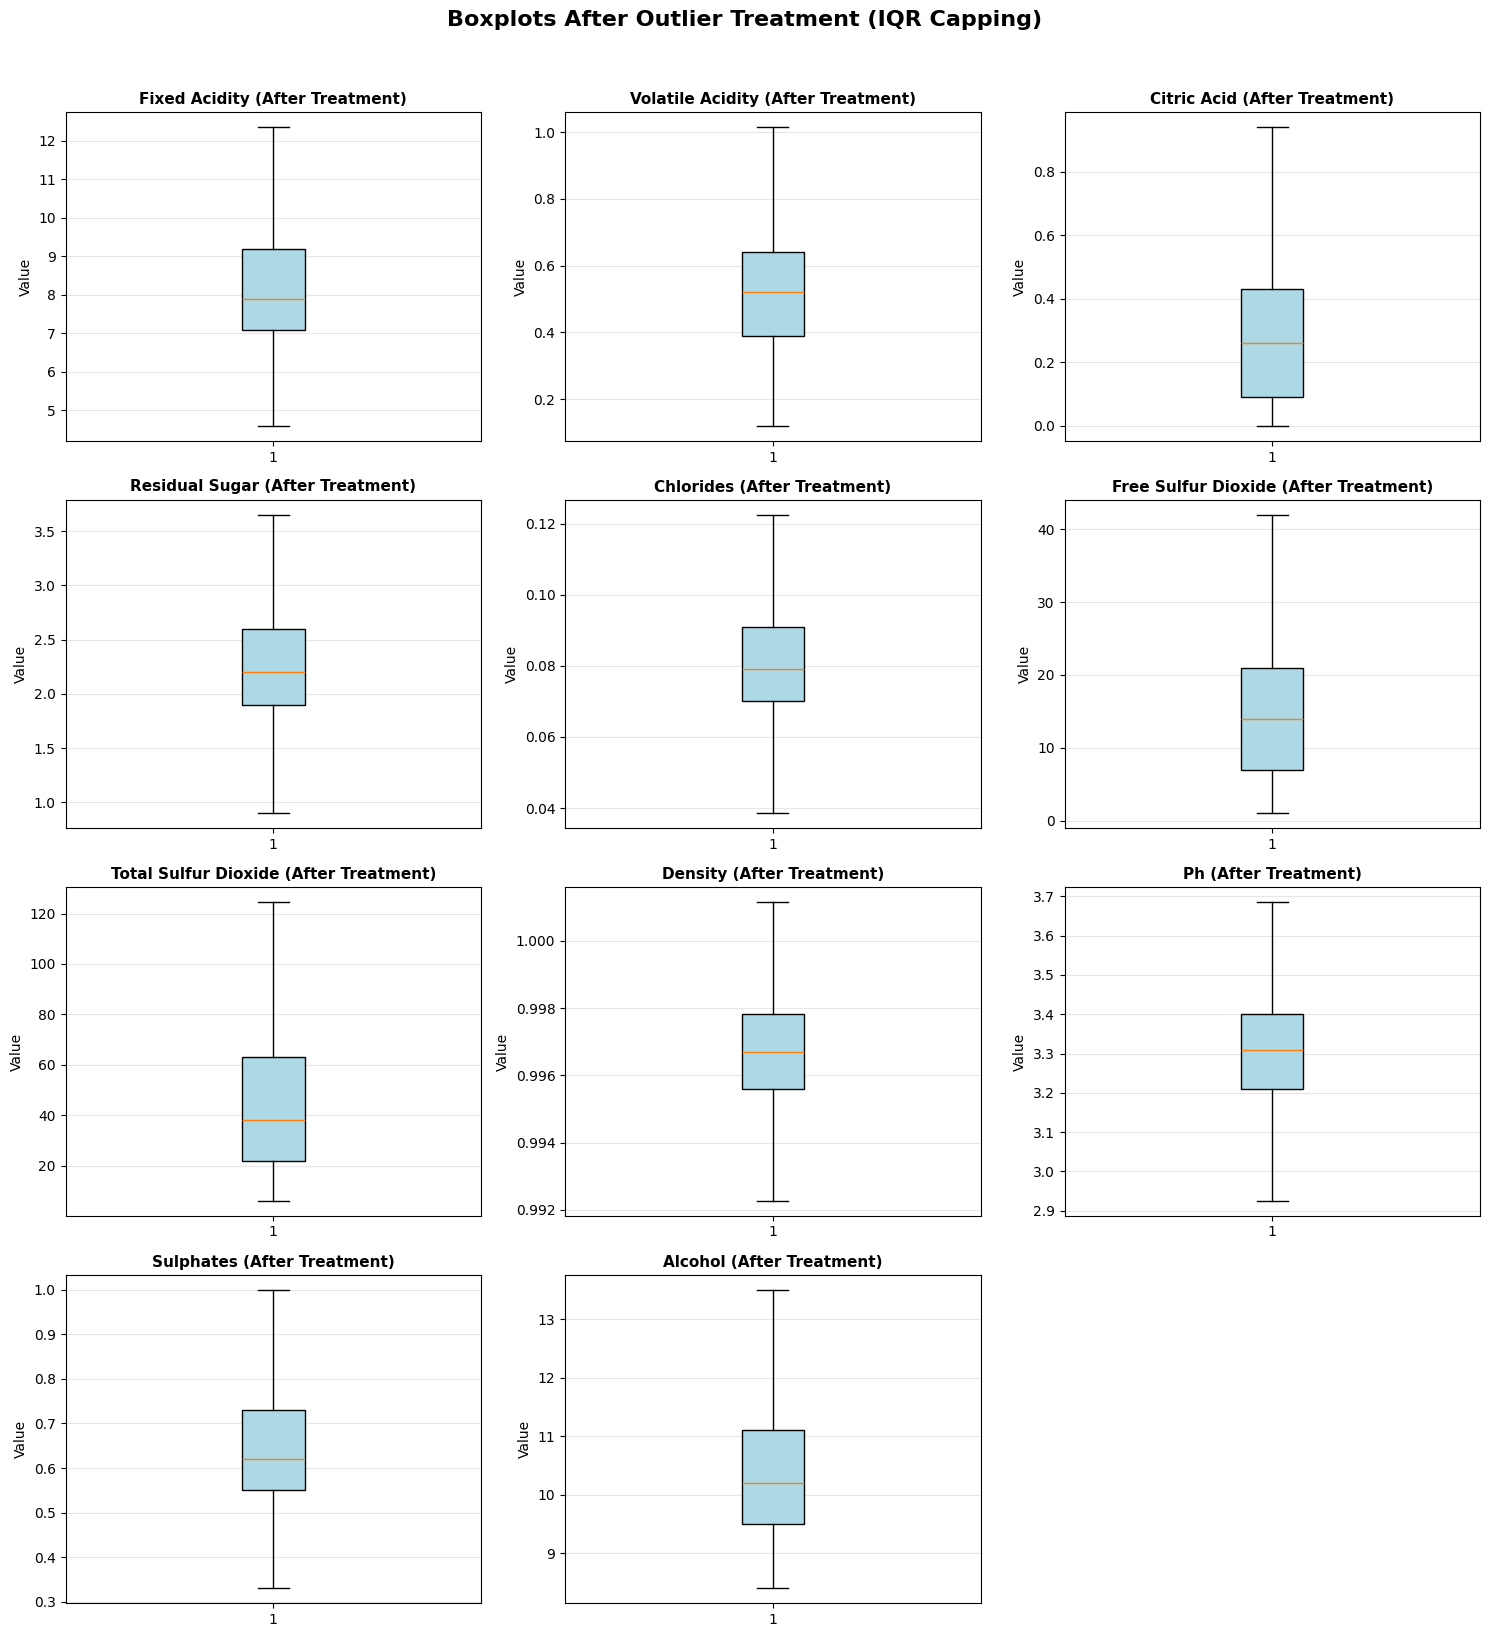

In [ ]:
import matplotlib.pyplot as plt

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(
        data[col],
        patch_artist=True,
        boxprops=dict(facecolor='lightblue')
    )

    axes[i].set_title(f"{col.replace('_', ' ').title()} (After Treatment)",
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', alpha=0.3)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Boxplots After Outlier Treatment (IQR Capping)',
    fontsize=16,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.show()


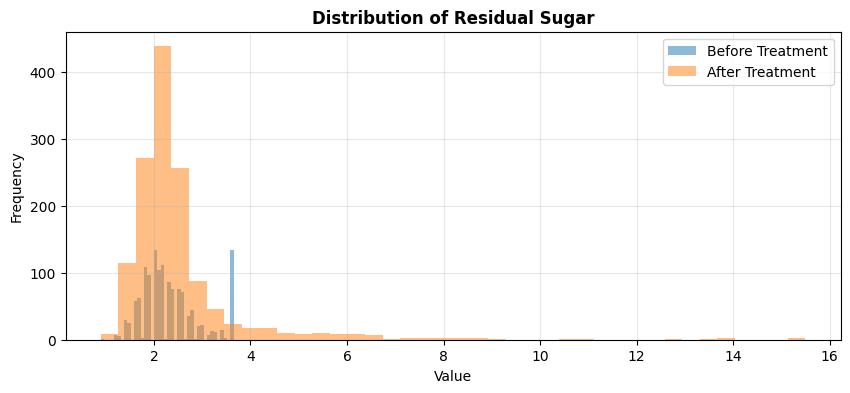

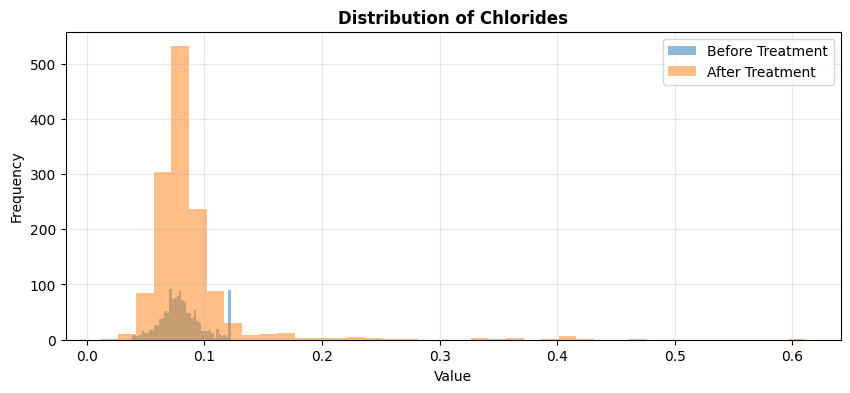

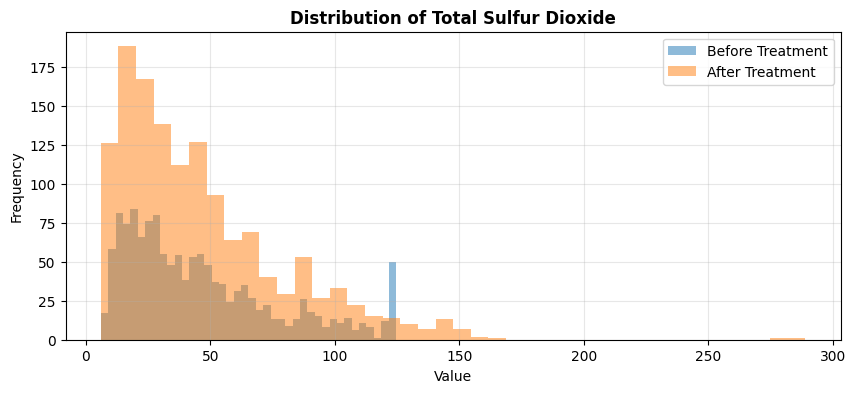

In [ ]:
import matplotlib.pyplot as plt

skewed_cols = ['residual_sugar', 'chlorides', 'total_sulfur_dioxide']

for col in skewed_cols:
    plt.figure(figsize=(10, 4))

    plt.hist(data[col], bins=40, alpha=0.5, label='Before Treatment')
    plt.hist(data_outlier_treated[col], bins=40, alpha=0.5, label='After Treatment')

    plt.title(f'Distribution of {col.replace("_", " ").title()}',
              fontsize=12, fontweight='bold')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()


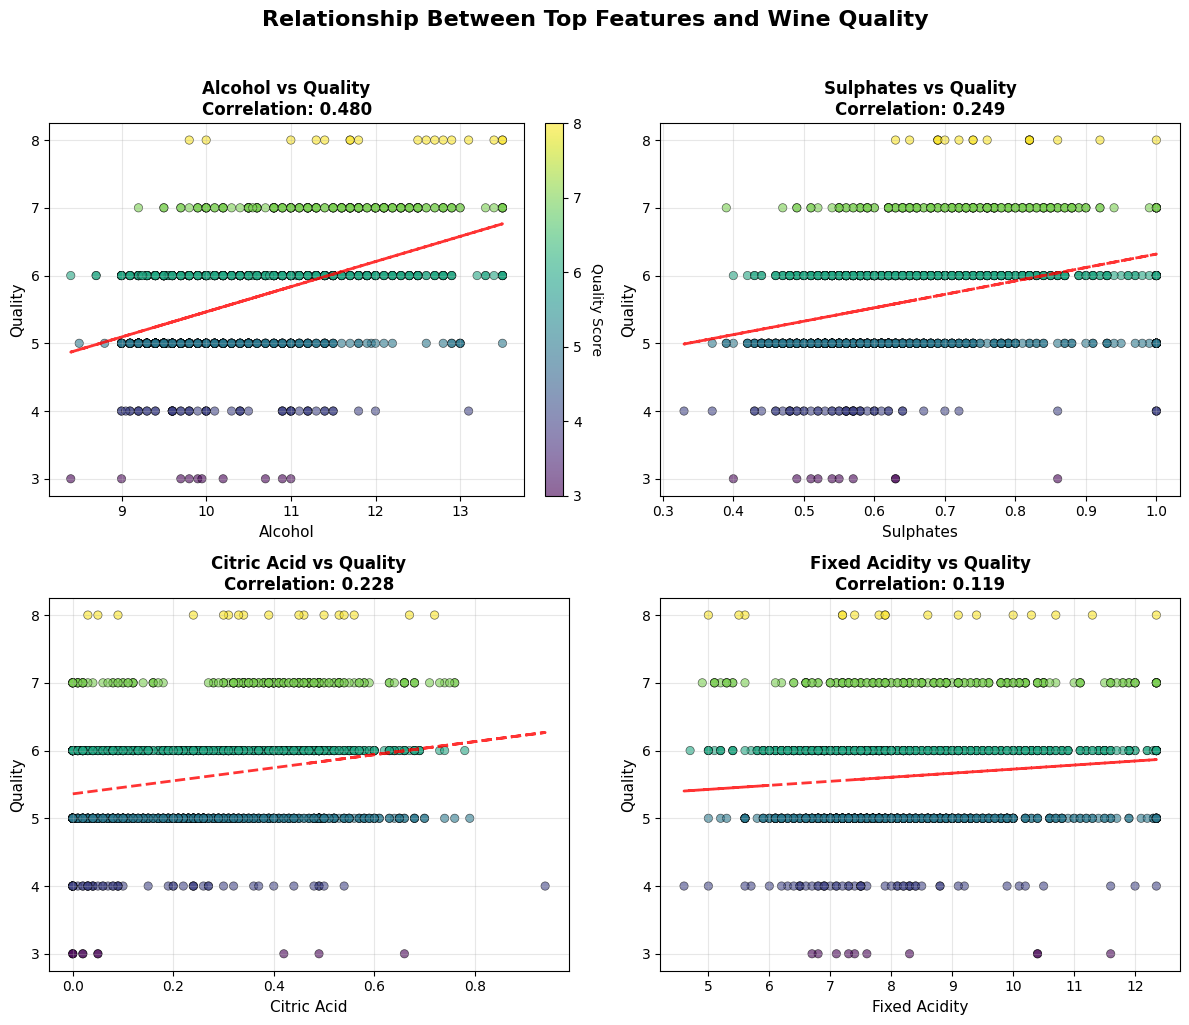

In [ ]:
# Get top 4 features correlated with quality
top_features = quality_corr.index[1:5]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    # Create scatter plot
    scatter = axes[i].scatter(data[feature], data['quality'],
                              c=data['quality'], cmap='viridis',
                              alpha=0.6, edgecolors='black', linewidth=0.5)

    # Add regression line
    z = np.polyfit(data[feature], data['quality'], 1)
    p = np.poly1d(z)
    axes[i].plot(data[feature], p(data[feature]),
                 "r--", alpha=0.8, linewidth=2)

    axes[i].set_xlabel(feature.replace('_', ' ').title(), fontsize=11)
    axes[i].set_ylabel('Quality', fontsize=11)
    axes[i].set_title(f'{feature.replace("_", " ").title()} vs Quality\nCorrelation: {quality_corr[feature]:.3f}',
                      fontsize=12, fontweight='bold')
    axes[i].grid(alpha=0.3)

    # Add colorbar for quality
    if i == 0:  # Add colorbar only once
        cbar = fig.colorbar(scatter, ax=axes[i], orientation='vertical', fraction=0.046, pad=0.04)
        cbar.set_label('Quality Score', rotation=270, labelpad=15)

plt.suptitle('Relationship Between Top Features and Wine Quality',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipython-input-368537972.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_means = data.groupby('quality_category')[feature].mean()
/tmp/ipython-input-368537972.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_stds = data.groupby('quality_category')[feature].std()
/tmp/ipython-input-368537972.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_means = data.groupby('quality_category'

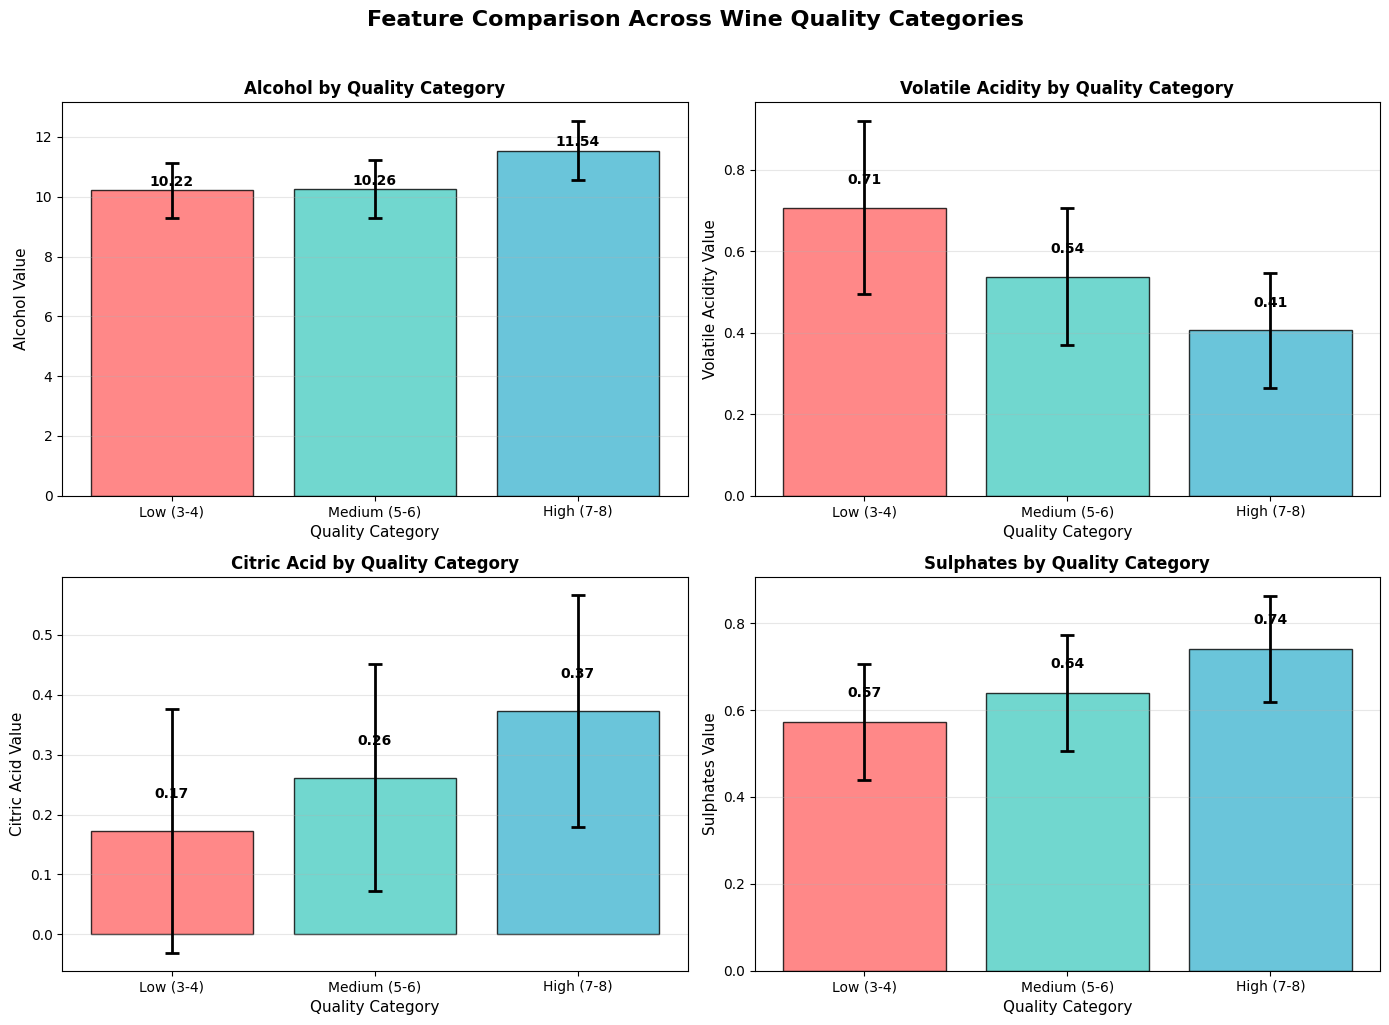

In [ ]:
# Define quality categories
data['quality_category'] = pd.cut(data['quality'],
                                      bins=[2, 4, 6, 9],
                                      labels=['Low (3-4)', 'Medium (5-6)', 'High (7-8)'])

# Select key features to compare
key_features = ['alcohol', 'volatile_acidity', 'citric_acid', 'sulphates']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    # Group by quality category
    category_means = data.groupby('quality_category')[feature].mean()
    category_stds = data.groupby('quality_category')[feature].std()

    x_pos = np.arange(len(category_means))

    # Create bar chart with error bars
    bars = axes[i].bar(x_pos, category_means.values,
                       yerr=category_stds.values,
                       color=['#FF6B6B', '#4ECDC4', '#45B7D1'],
                       edgecolor='black', alpha=0.8,
                       capsize=5, error_kw={'elinewidth': 2, 'capthick': 2})

    # Add value labels
    for bar, value in zip(bars, category_means.values):
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.05,
                    f'{value:.2f}', ha='center', va='bottom', fontweight='bold')

    axes[i].set_xlabel('Quality Category', fontsize=11)
    axes[i].set_ylabel(f'{feature.replace("_", " ").title()} Value', fontsize=11)
    axes[i].set_title(f'{feature.replace("_", " ").title()} by Quality Category',
                      fontsize=12, fontweight='bold')
    axes[i].set_xticks(x_pos)
    axes[i].set_xticklabels(category_means.index, rotation=0)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Comparison Across Wine Quality Categories',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

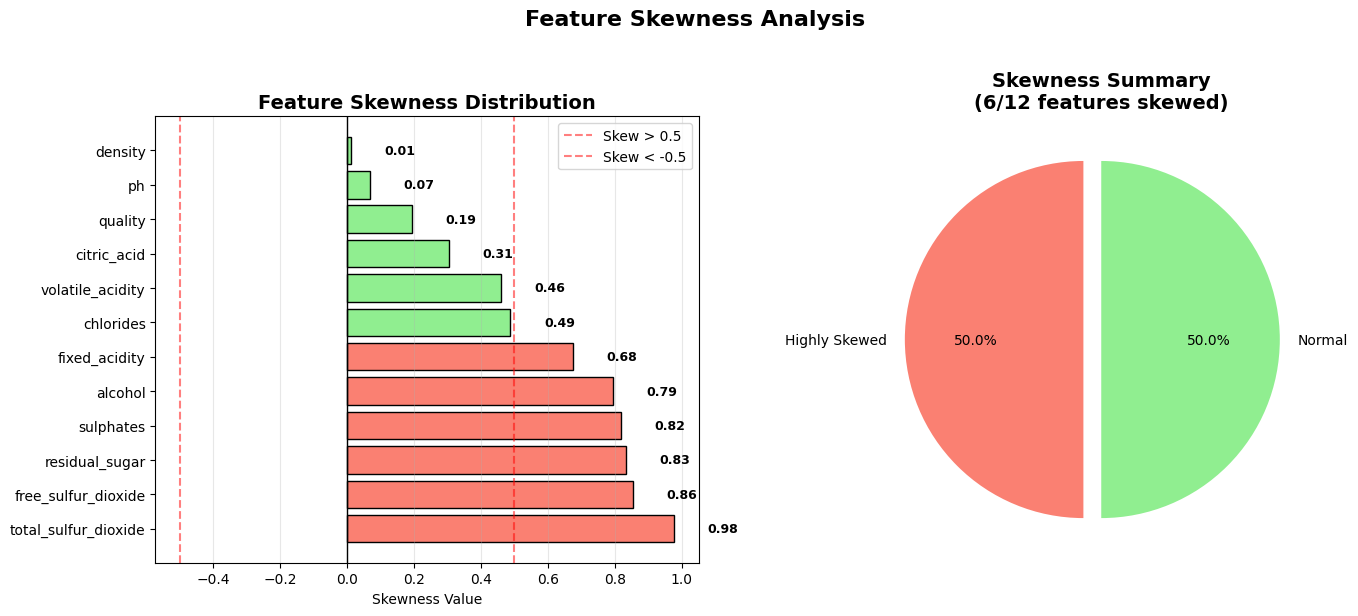

In [ ]:
# Calculate skewness, excluding non-numeric columns
skewness = data.skew(numeric_only=True).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart of skewness
bars = ax1.barh(range(len(skewness)), skewness.values,
                color=np.where(np.abs(skewness.values) > 0.5, 'salmon', 'lightgreen'),
                edgecolor='black')
ax1.set_yticks(range(len(skewness)))
ax1.set_yticklabels(skewness.index)
ax1.axvline(x=0, color='black', linewidth=1)
ax1.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Skew > 0.5')
ax1.axvline(x=-0.5, color='red', linestyle='--', alpha=0.5, label='Skew < -0.5')
ax1.set_xlabel('Skewness Value')
ax1.set_title('Feature Skewness Distribution', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, skewness.values)):
    ax1.text(val + (0.1 if val >= 0 else -0.1), i, f'{val:.2f}',
             va='center', ha='left' if val >= 0 else 'right',
             fontweight='bold', fontsize=9)

# Pie chart showing proportion of skewed features
skewed_count = sum(np.abs(skewness.values) > 0.5)
normal_count = len(skewness) - skewed_count
ax2.pie([skewed_count, normal_count],
        labels=['Highly Skewed', 'Normal'],
        colors=['salmon', 'lightgreen'],
        autopct='%1.1f%%', startangle=90,
        explode=(0.1, 0))
ax2.set_title(f'Skewness Summary\n({skewed_count}/{len(skewness)} features skewed)',
              fontsize=14, fontweight='bold')

plt.suptitle('Feature Skewness Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# **Model Training**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, precision_score, recall_score, f1_score, average_precision_score
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
data['quality_label'] = data['quality'].apply(lambda x: 1 if x >= 7 else 0)

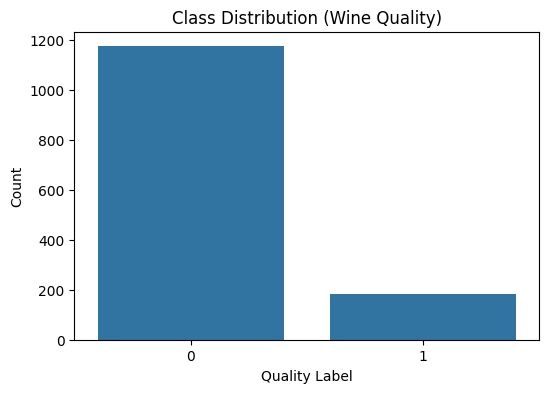

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=data['quality_label'])
plt.title("Class Distribution (Wine Quality)")
plt.xlabel("Quality Label")
plt.ylabel("Count")
plt.show()


In [ ]:
X = data.drop(['quality', 'quality_label', 'quality_category'], axis=1)
y = data['quality_label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    oob_score=True
)

In [ ]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

In [ ]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=60,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(oob_score=True,
                                                    random_state=42),
                   n_iter=60, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'class_weight': [None, 'balanced'],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 300, 500]},
                   random_state=42, scoring='accuracy', verbose=1)

In [ ]:
best_rf = random_search.best_estimator_

In [ ]:
rf_pred = best_rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Best Parameters:", random_search.best_params_)
print("Random Forest Accuracy:", rf_accuracy)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'gini', 'class_weight': None, 'bootstrap': True}
Random Forest Accuracy: 0.8933823529411765


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       235
           1       0.75      0.32      0.45        37

    accuracy                           0.89       272
   macro avg       0.83      0.65      0.70       272
weighted avg       0.88      0.89      0.87       272



In [ ]:
rf_cm = confusion_matrix(y_test, rf_pred)

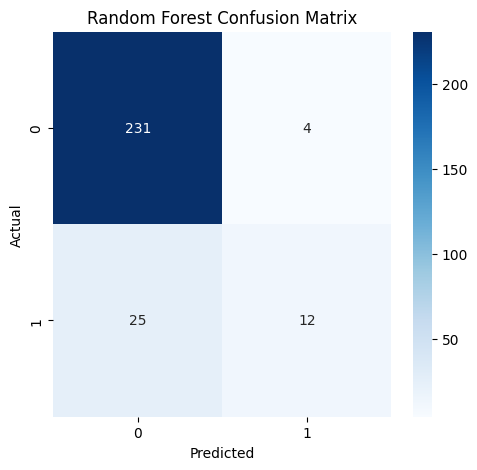

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

In [ ]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)


In [ ]:
param_dist = {
    'n_estimators': [300, 500, 800, 1200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

In [ ]:
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=60,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [ ]:
random_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           num_parallel_tree=None, ...),
                   n_iter=60, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.03, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [300, 500, 800, 1200],
                                        'reg_alpha': [0, 0.01, 0.1],
                                        'reg_lambda': [1, 1.5, 2],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='accuracy', verbose=1)

In [ ]:
best_xgb = random_search_xgb.best_estimator_

In [ ]:
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

In [ ]:
accuracy_xg = accuracy_score(y_test, y_pred)
roc_auc_xg = roc_auc_score(y_test, y_prob)

print("Best XGBoost Parameters:")
print(random_search_xgb.best_params_)

print("\nModel Performance:")
print(f"Accuracy: {accuracy_xg:.4f}")
print(f"ROC-AUC: {roc_auc_xg:.4f}")

Best XGBoost Parameters:
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}

Model Performance:
Accuracy: 0.8824
ROC-AUC: 0.8799


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       235
           1       0.59      0.46      0.52        37

    accuracy                           0.88       272
   macro avg       0.75      0.70      0.72       272
weighted avg       0.87      0.88      0.88       272



In [ ]:
xgb_cm = confusion_matrix(y_test, y_pred)

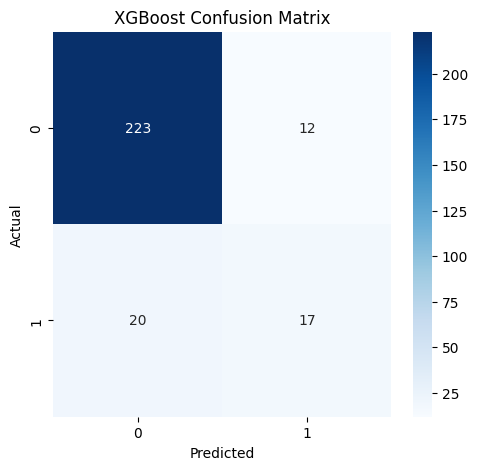

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
neg, pos = np.bincount(y_train)
class_weight = {0: 1, 1: neg / pos}

In [ ]:
log_reg = LogisticRegression(
    random_state=42,
    max_iter=5000
)

In [ ]:
param_dist = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': np.logspace(-3, 2, 20),
    'solver': ['saga'],
    'l1_ratio': [0, 0.25, 0.5, 0.75, 1]
}

In [ ]:
random_search_lr = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=60,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [ ]:
random_search_lr.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=LogisticRegression(max_iter=5000, random_state=42),
                   n_iter=60, n_jobs=-1,
                   param_distributions={'C': array([1.00000000e-03, 1.83298071e-03, 3.35981829e-03, 6.15848211e-03,
       1.12883789e-02, 2.06913808e-02, 3.79269019e-02, 6.95192796e-02,
       1.27427499e-01, 2.33572147e-01, 4.28133240e-01, 7.84759970e-01,
       1.43844989e+00, 2.63665090e+00, 4.83293024e+00, 8.85866790e+00,
       1.62377674e+01, 2.97635144e+01, 5.45559478e+01, 1.00000000e+02]),
                                        'l1_ratio': [0, 0.25, 0.5, 0.75, 1],
                                        'penalty': ['l1', 'l2', 'elasticnet'],
                                        'solver': ['saga']},
                   random_state=42, scoring='accuracy', verbose=1)

In [ ]:
best_lr = random_search_lr.best_estimator_

In [ ]:
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

In [ ]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Best Logistic Regression Parameters:")
print(random_search_lr.best_params_)

print("\nLogistic Regression Performance:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"ROC-AUC: {roc_auc_lr:.4f}")

Best Logistic Regression Parameters:
{'solver': 'saga', 'penalty': 'l1', 'l1_ratio': 0.75, 'C': np.float64(0.23357214690901212)}

Logistic Regression Performance:
Accuracy: 0.8750
ROC-AUC: 0.8539


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       235
           1       0.67      0.16      0.26        37

    accuracy                           0.88       272
   macro avg       0.77      0.57      0.60       272
weighted avg       0.85      0.88      0.84       272



In [ ]:
lr_cm = confusion_matrix(y_test, y_pred_lr)

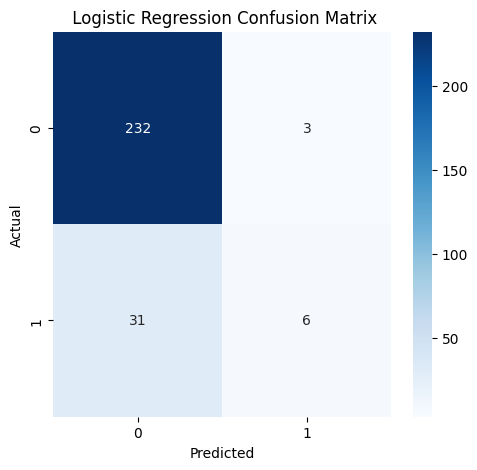

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')
plt.title(" Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = best_rf.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8776308223116734


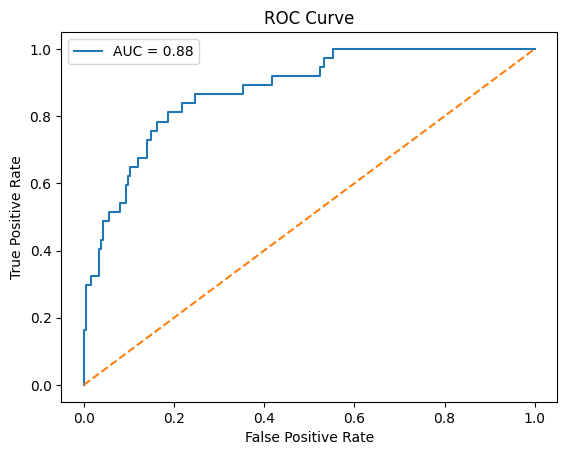

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_lr, rf_accuracy, accuracy_xg]
})

In [ ]:
results

,Model,Accuracy
0,Logistic Regression,0.875000
1,Random Forest,0.893382
2,XGBoost,0.882353


In [ ]:
import time
from sklearn.metrics import log_loss
from sklearn.model_selection import learning_curve

def plot_learning_curve(ax, model, title, X, y):
    start_time = time.time()

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=10,
        scoring='accuracy',
        n_jobs=-1,
        shuffle=True,
        random_state=42,
        train_sizes=np.linspace(0.1, 1.0, 15)
    )

    elapsed_time = time.time() - start_time

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    # -------------------
    # GAP
    # -------------------
    gap = train_mean[-1] - val_mean[-1]

    # -------------------
    # Entropy (Log Loss)
    # -------------------
    model.fit(X, y)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)
        entropy = log_loss(y, y_prob)
    else:
        entropy = np.nan

    # -------------------
    # Plot curves
    # -------------------
    ax.plot(train_sizes, train_mean, 'o-', label='Training')
    ax.plot(train_sizes, val_mean, 'o-', label='Validation')

    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15
    )
    ax.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15
    )

    ax.set_title(title)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

    # -------------------
    # METRICS TEXT BOX
    # -------------------
    stats_text = (
        f"Start Train Acc : {train_mean[0]:.3f}\n"
        f"Final Train Acc : {train_mean[-1]:.3f}\n"
        f"Final Val Acc   : {val_mean[-1]:.3f}\n"
        f"Gap             : {gap:.3f}\n"
        f"Entropy         : {entropy:.3f}\n"
        f"Time (s)        : {elapsed_time:.2f}"
    )

    ax.text(
        1.02, 0.5,
        stats_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='center',
        bbox=dict(boxstyle="round", alpha=0.2)
    )


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        C=0.4,
        max_iter=3000,
        random_state=42
    ))
])


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)


In [ ]:
xgb = XGBClassifier(
    n_estimators=350,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.6,
    reg_lambda=1.0,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)


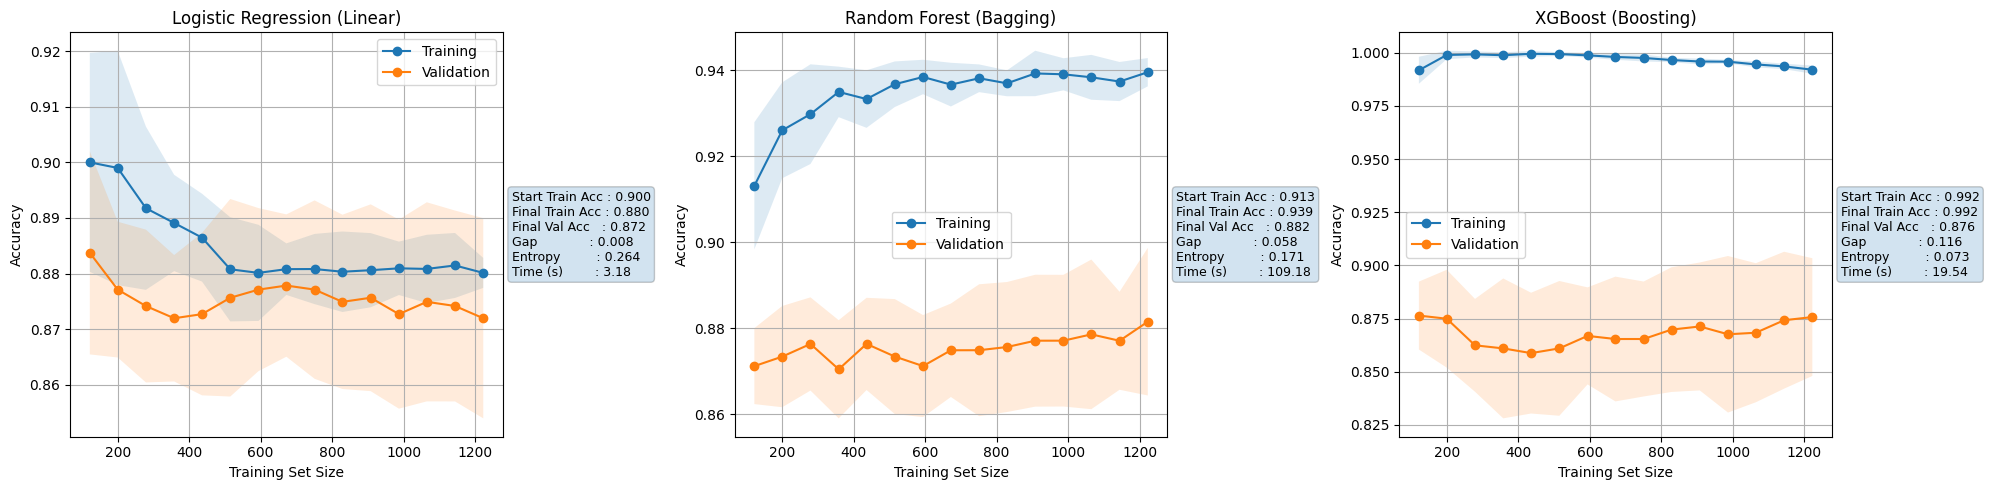

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_learning_curve(
    axes[0],
    log_reg,
    'Logistic Regression (Linear)',
    X, y
)

plot_learning_curve(
    axes[1],
    rf,
    'Random Forest (Bagging)',
    X, y
)

plot_learning_curve(
    axes[2],
    xgb,
    'XGBoost (Boosting)',
    X, y
)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def plot_feature_importance(ax, model, X, title, model_type, top_n=10):
    feature_names = X.columns

    if model_type == 'log_reg':
        importance = np.abs(model.named_steps['model'].coef_[0])

    elif model_type == 'rf':
        importance = model.feature_importances_

    elif model_type == 'xgb':
        importance = model.feature_importances_

    else:
        raise ValueError("Invalid model type")

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False).head(top_n)

    ax.barh(
        importance_df['Feature'][::-1],
        importance_df['Importance'][::-1]
    )

    ax.set_title(title)
    ax.set_xlabel('Importance')
    ax.grid(True)


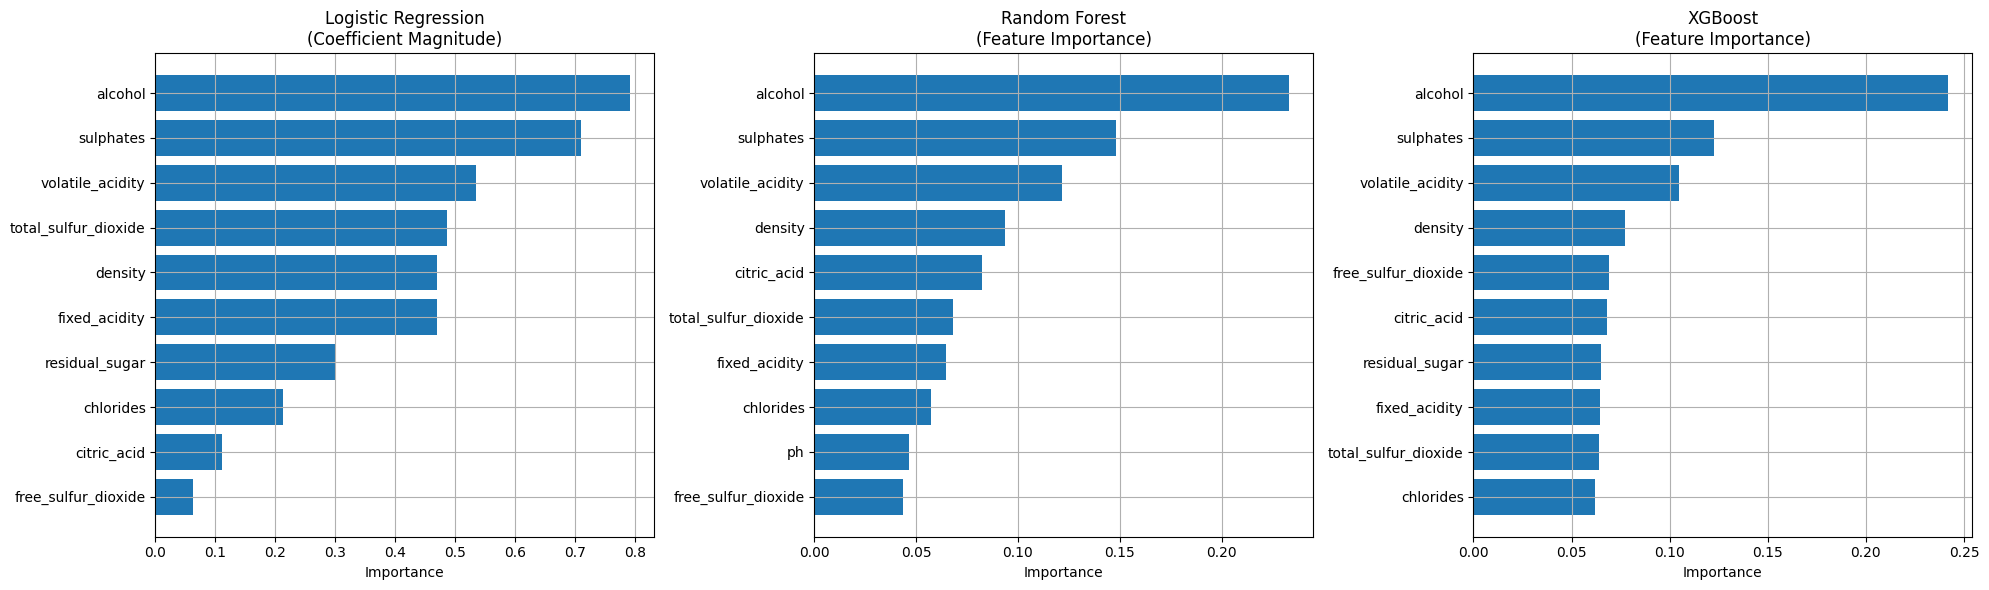

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_feature_importance(
    axes[0],
    log_reg,
    X,
    'Logistic Regression\n(Coefficient Magnitude)',
    model_type='log_reg'
)

plot_feature_importance(
    axes[1],
    rf,
    X,
    'Random Forest\n(Feature Importance)',
    model_type='rf'
)

plot_feature_importance(
    axes[2],
    xgb,
    X,
    'XGBoost\n(Feature Importance)',
    model_type='xgb'
)

plt.tight_layout()
plt.show()


In [ ]:
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):

    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_pred

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    pr_auc  = average_precision_score(y_test, y_prob) if y_prob is not None else None

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR AUC': pr_auc,
        'Training Time (s)': train_time,
        'Prediction Time (s)': pred_time
    }


In [ ]:
results = []

results.append(
    evaluate_model(log_reg, 'Logistic Regression', X_train, X_test, y_train, y_test)
)

results.append(
    evaluate_model(rf, 'Random Forest', X_train, X_test, y_train, y_test)
)

results.append(
    evaluate_model(xgb, 'XGBoost', X_train, X_test, y_train, y_test)
)


In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.round(4)

display(results_df)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR AUC,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.8750,0.5882,0.2703,0.3704,0.8942,0.5467,0.0117,0.0026
1,Random Forest,0.8897,0.7333,0.2973,0.4231,0.8798,0.5967,0.8968,0.0989
2,XGBoost,0.8934,0.6538,0.4595,0.5397,0.8869,0.5810,0.1548,0.0048
